# Notebook overview

This notebook loads processed hourly AQUM gridded fields and AQUM values extracted at AURN sites, then interpolates site ozone values back onto the AQUM grid using multiple methods (SciPy griddata and kriging variants). It generates comparison plots of the original gridded ozone and interpolated fields over the UK domain, and includes diagnostics/visual checks to support preprocessing quality control before downstream machine-learning steps.

# Import things

In [1]:
import warnings

import numpy as np

from matplotlib import pyplot as plt

from scipy.interpolate import griddata

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from pykrige.rk import Krige
from sklearn.model_selection import GridSearchCV

import iris
from iris.analysis.cartography import unrotate_pole
iris.FUTURE.save_split_attrs = True
# iris.FUTURE.datum_support = False
# turn off futurewarning from iris
warnings.filterwarnings("ignore", category=FutureWarning)
# turn off netcdf unknown variable warning from iris
warnings.filterwarnings("ignore", category=UserWarning, message=".*NetCDF variable.*")
# turn off IrisCfNonSpanningVarWarning
warnings.filterwarnings("ignore", category=UserWarning, message=".*IrisCfNonSpanningVarWarning.*")

/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# My functions

## Interpolation function

In [2]:
def interpolation(sites_ozone, sites_rotated_lat, sites_rotated_lon, lon_grid, lat_grid):
    '''Interpolate ozone from the gridded model field to the AURN site locations using various methods.'''

    # ------------------------
    # Sample scattered points
    # ------------------------
    rot_lats_obs = np.array(sites_rotated_lat)
    rot_lons_obs = np.array(sites_rotated_lon)
    values = np.array(sites_ozone)

    # -----------------------------------
    # Define the target regular lat/lon grid (use rotated grid from AQUM)
    # -----------------------------------
    lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------------
    # Basic Interpolation (griddata from scipy)
    # -----------------------------------
    interpol_type = 'cubic'  # 'nearest', 'linear', 'cubic'
    interpol_type = 'nearest' 
    interpol_type = 'linear' 

    points = np.column_stack((rot_lats_obs, rot_lons_obs))
    grid_points = np.column_stack((lat2d.ravel(), lon2d.ravel()))

    interpolated_values = griddata(
        points, values, grid_points,
        method = interpol_type   # linear interpolation
    )

    interpolated_values = interpolated_values.reshape(lat2d.shape)  # back to 2D

    # -----------------------------------
    # Kriging interpolation (optional, more complex)
    # -----------------------------------
    # 1. Define the kernel (e.g., Squared Exponential / RBF)
    # 'kriging' range is controlled by length_scale
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

    # 2. Instantiate and fit the model
    # alpha corresponds to the 'nugget' effect (noise)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1)
    X_train = np.column_stack((rot_lats_obs, rot_lons_obs))
    Y_train = values
    gp.fit(X_train, Y_train)

    # 3. Predict values and uncertainty (standard deviation)
    X_grid = np.column_stack((lat2d.ravel(), lon2d.ravel()))
    y_pred, sigma = gp.predict(X_grid, return_std=True)
    kriging_values = y_pred.reshape(lat2d.shape)  # back to 2D  

    # -----------------------------------
    # Kriging with PyKrige
    # -----------------------------------
    # Define the wrapper with your chosen method ('ordinary' or 'universal')
    # and a variogram model (e.g., 'spherical', 'gaussian', 'exponential')
    estimator = Krige(method='ordinary', variogram_model='spherical')

    # Define parameters for a Grid Search
    param_dict = {
        "method": ["ordinary", "universal"],
        "variogram_model": ["linear", "gaussian", "spherical"],
    }

    # Use scikit-learn's GridSearchCV to find the best parameters
    grid_search = GridSearchCV(estimator, param_dict, cv=5)
    X_train = np.column_stack((rot_lats_obs, rot_lons_obs))
    Y_train = values
    grid_search.fit(X_train, Y_train)

    # Predict as you would with any sklearn model
    X_test = np.column_stack((lat2d.ravel(), lon2d.ravel()))
    predictions = grid_search.predict(X_test)
    kriging_v2_values = predictions.reshape(lat2d.shape)  # back to 2D  

    return interpolated_values, kriging_values, kriging_v2_values, interpol_type

## Plotting panel of  interpolated values

In [3]:
## Interpolate sites to UM grid
def plotting_interpolated_fields(ozone_field_cube,
                                 sites_ozone,
                                 interpolated_values,
                                 kriging_values,
                                 kriging_v2_values,
                                 date_str,
                                 interpol_type,
                                 lats_obs,
                                 lons_obs,
                                 lon2d_unrotated,
                                 lat2d_unrotated
                                 ):
    '''Plot the original gridded field and the interpolated fields at the AURN site locations.'''   

    # -----------------------------------
    # plotting
    # -----------------------------------
    fig = plt.figure(figsize=(16,12))
    cmap = 'Spectral_r' 
    min_o3 = 50
    max_o3 = 125

    # 1 - plot gridded ozone field from AQUM
    ax1 = fig.add_subplot(2,2,1)
    pcm2 = ax1.pcolormesh(lon2d_unrotated, lat2d_unrotated, ozone_field_cube.data, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
    fig.colorbar(pcm2, ax=ax1, label='O3')
    ax1.set_title(f'Gridded O3 from AQUM')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')  
    scatter = ax1.scatter(lons_obs, lats_obs, c=sites_ozone, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)

    # 2 - plot interpolated field
    ax2 = fig.add_subplot(2,2,2)
    pcm = ax2.pcolormesh(lon2d_unrotated, lat2d_unrotated, interpolated_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
    fig.colorbar(pcm, ax=ax2, label='O3')
    ax2.set_title(f'O3 at AURN sites (with {interpol_type} interpolation)')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    # #overlay original points
    # ax2.scatter(lons_obs, lats_obs, c='red', edgecolor='black', label='Observations')
    # color original points by their values
    scatter = ax2.scatter(lons_obs, lats_obs, c=sites_ozone, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
    ax2.legend() 

    # 3 - plot interpolated field with kriging
    ax3 = fig.add_subplot(2,2,3)
    pcm3 = ax3.pcolormesh(lon2d_unrotated, lat2d_unrotated, kriging_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
    fig.colorbar(pcm3, ax=ax3, label='O3 (kriging)')
    ax3.set_title(f'O3 at AURN sites (with kriging interpolation)')
    ax3.set_xlabel('Longitude')
    ax3.set_ylabel('Latitude')
    scatter = ax3.scatter(lons_obs, lats_obs, c=sites_ozone, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
    ax3.legend()

    # 4 - plot interpolated field with kriging using PyKrige
    ax4 = fig.add_subplot(2,2,4)
    pcm4 = ax4.pcolormesh(lon2d_unrotated, lat2d_unrotated, kriging_v2_values, cmap=cmap, shading='auto', vmin=min_o3, vmax=max_o3)
    fig.colorbar(pcm4, ax=ax4, label='O3 (kriging PyKrige)')
    ax4.set_title(f'O3 at AURN sites (with kriging interpolation using PyKrige)')
    ax4.set_xlabel('Longitude')
    ax4.set_ylabel('Latitude')
    scatter = ax4.scatter(lons_obs, lats_obs, c=sites_ozone, cmap=cmap, edgecolor='black', label='Observations', vmin=min_o3, vmax=max_o3)
    ax4.legend()

    # # UK map window (unrotated lon/lat)
    # uk_lon_min, uk_lon_max = -11.0, 3.0
    # uk_lat_min, uk_lat_max = 48.0, 61.5

    # # Apply UK zoom to all panels
    # for ax in (ax1, ax2, ax3, ax4):
    #     ax.set_xlim(uk_lon_min, uk_lon_max)
    #     ax.set_ylim(uk_lat_min, uk_lat_max)

    # add title with date
    fig.suptitle(f'Ozone interpolation at AURN sites for {date_str}', fontsize=16)

    # Show plot 
    plt.show()

# Processing

## Loading processed hourly mean data

In [4]:
# load the hourly means from post processed files
model_datadir = 'processed_data/'
gridded_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_gridded_cube_list_hourly_means.nc')
site_cube_list_hourly = iris.load(model_datadir + '/AQUM-C_sites_cube_list_hourly_means.nc')

print(f"\nGridded cube list after loading hourly means:")
print(gridded_cube_list_hourly)
print(f"\nSite cube list after loading hourly means:")
print(site_cube_list_hourly)

Ozone_constraint = iris.AttributeConstraint(short_name='O3')
ozone_gridded = gridded_cube_list_hourly.extract_cube(Ozone_constraint)
ozone_sites = site_cube_list_hourly.extract_cube(Ozone_constraint)


Gridded cube list after loading hourly means:
0: daily_air_quality_index_of_sulfur_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
1: daily_air_quality_index_of_nitrogen_monoxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
2: daily_air_quality_index / (1)       (time: 93; grid_latitude: 112; grid_longitude: 88)
3: daily_air_quality_index_of_nitrogen_dioxide / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
4: daily_air_quality_index_of_ozone / (1) (time: 93; grid_latitude: 112; grid_longitude: 88)
5: air_pressure_at_sea_level / (Pa)    (time: 2209; grid_latitude: 112; grid_longitude: 88)
6: air_temperature / (K)               (time: 2209; grid_latitude: 112; grid_longitude: 88)
7: mass_concentration_of_ammonia_in_air / (ug/m3) (time: 737; grid_latitude: 112; grid_longitude: 88)
8: mass_concentration_of_nitrogen_dioxide_in_air / (ug/m3) (time: 2209; grid_latitude: 112; grid_longitude: 88)
9: mass_concentration_of_nitrogen_monoxide_in_air / (ug/m3) (

## Interpolate UM hourly value at sites onto UM grid and plot

0 - Processing cubes for date: 2025-05-01 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


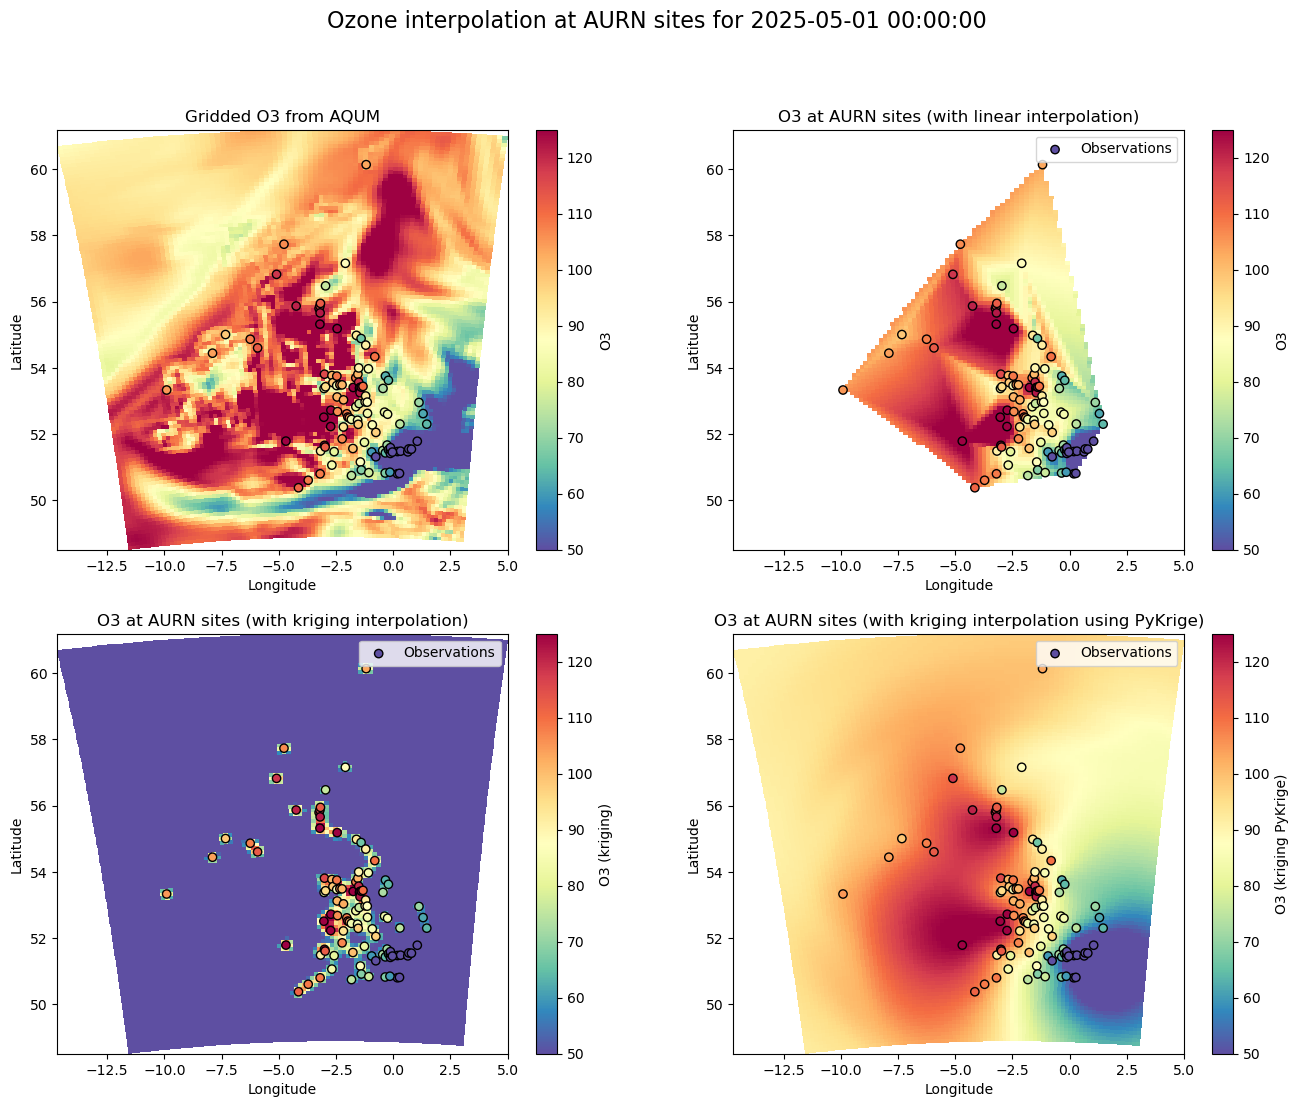

24 - Processing cubes for date: 2025-05-02 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


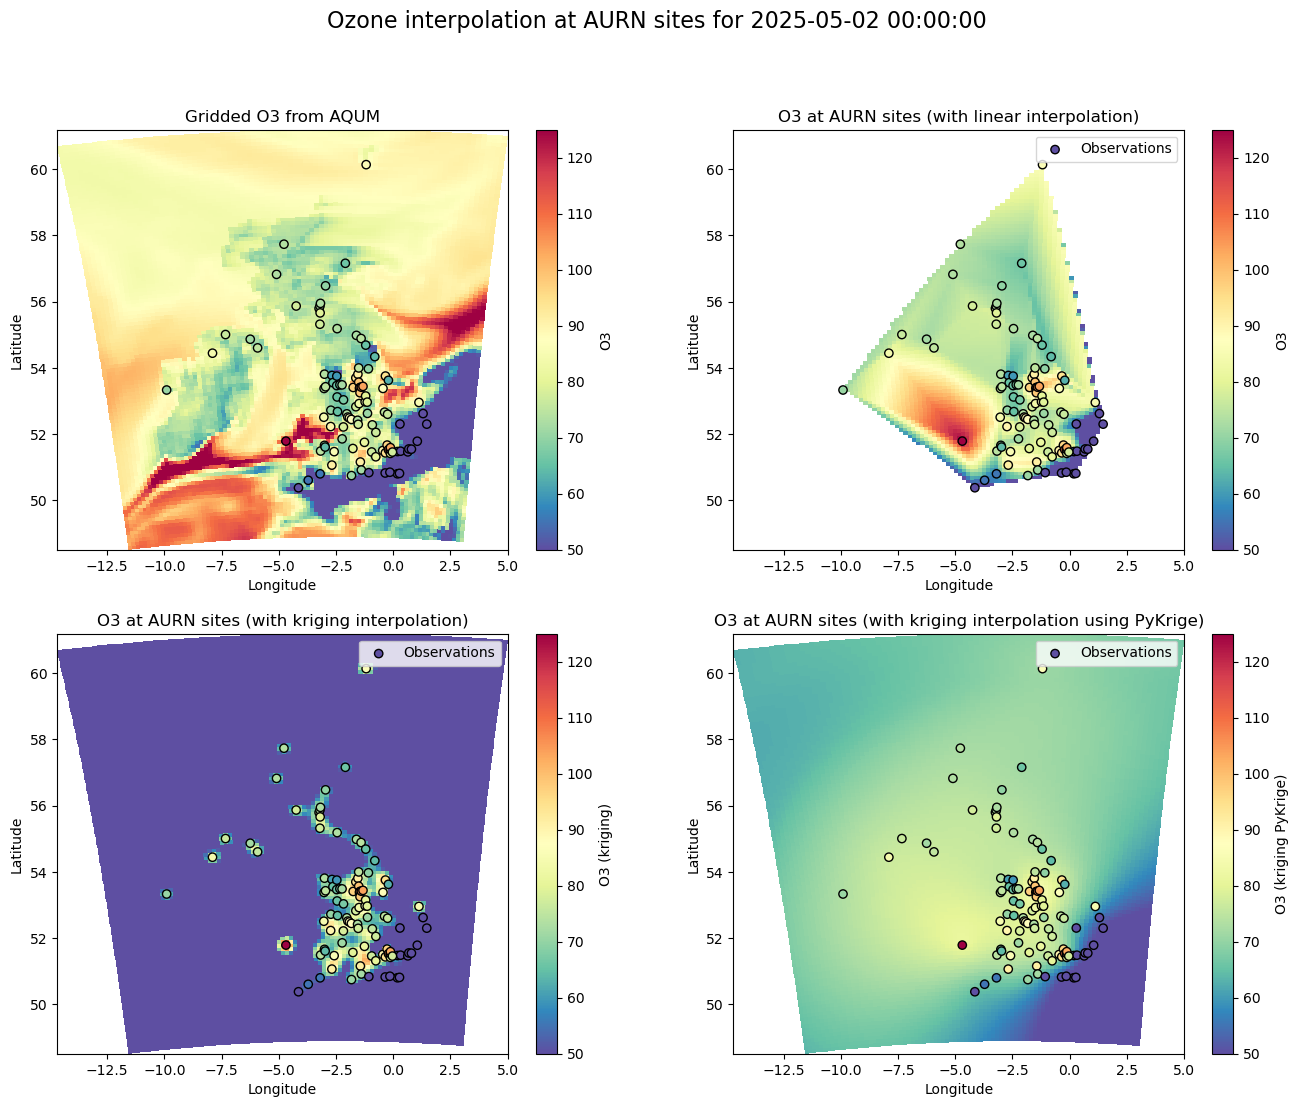

48 - Processing cubes for date: 2025-05-03 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


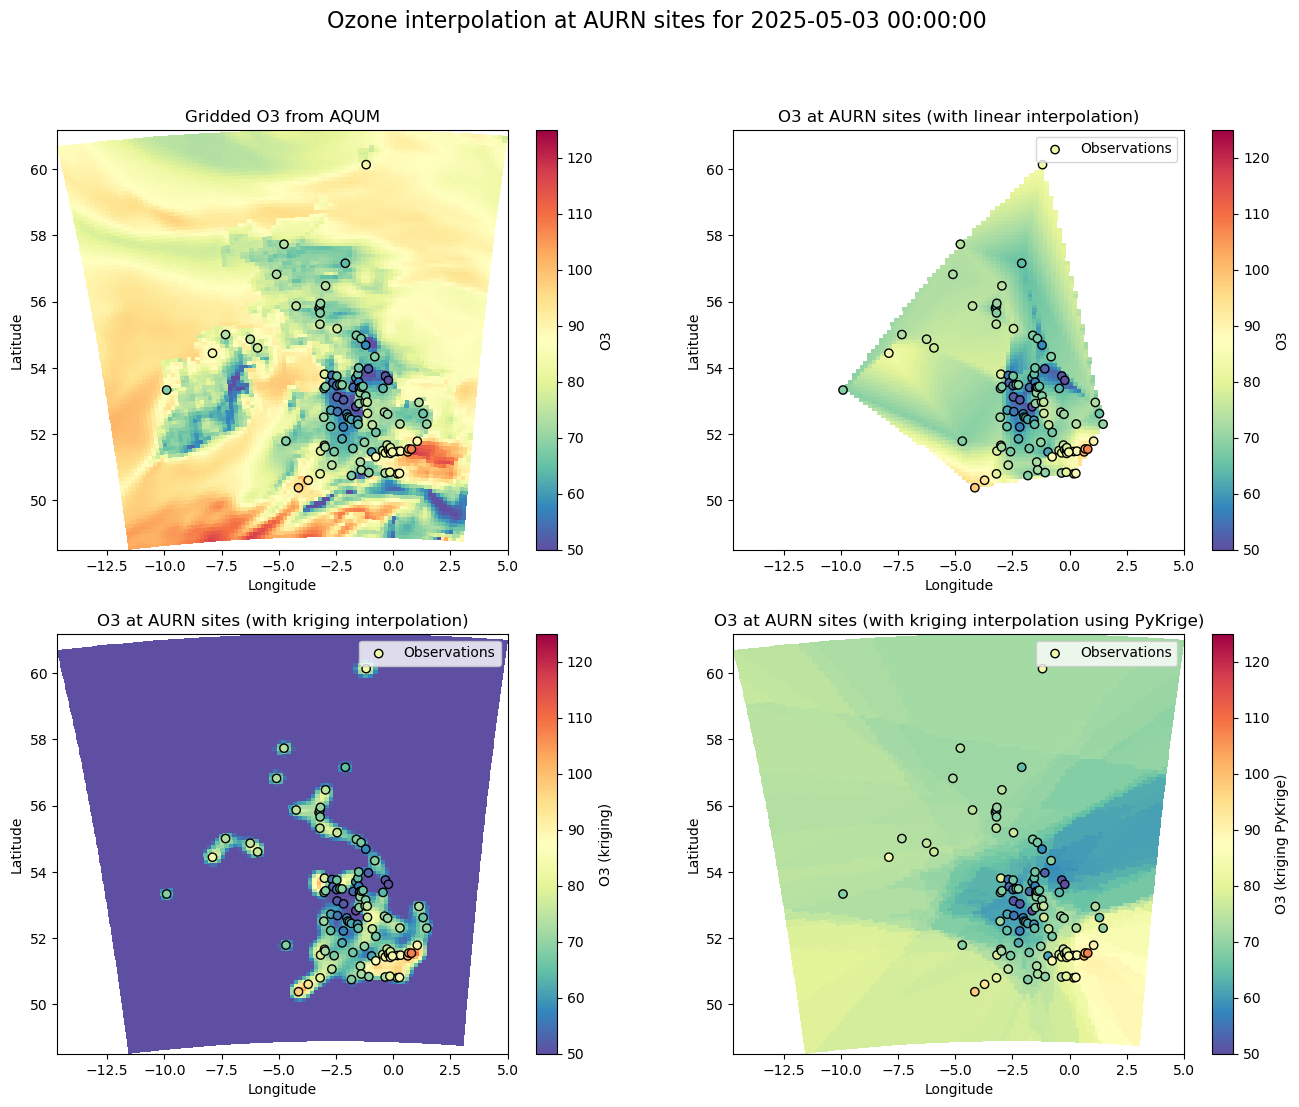

72 - Processing cubes for date: 2025-05-04 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


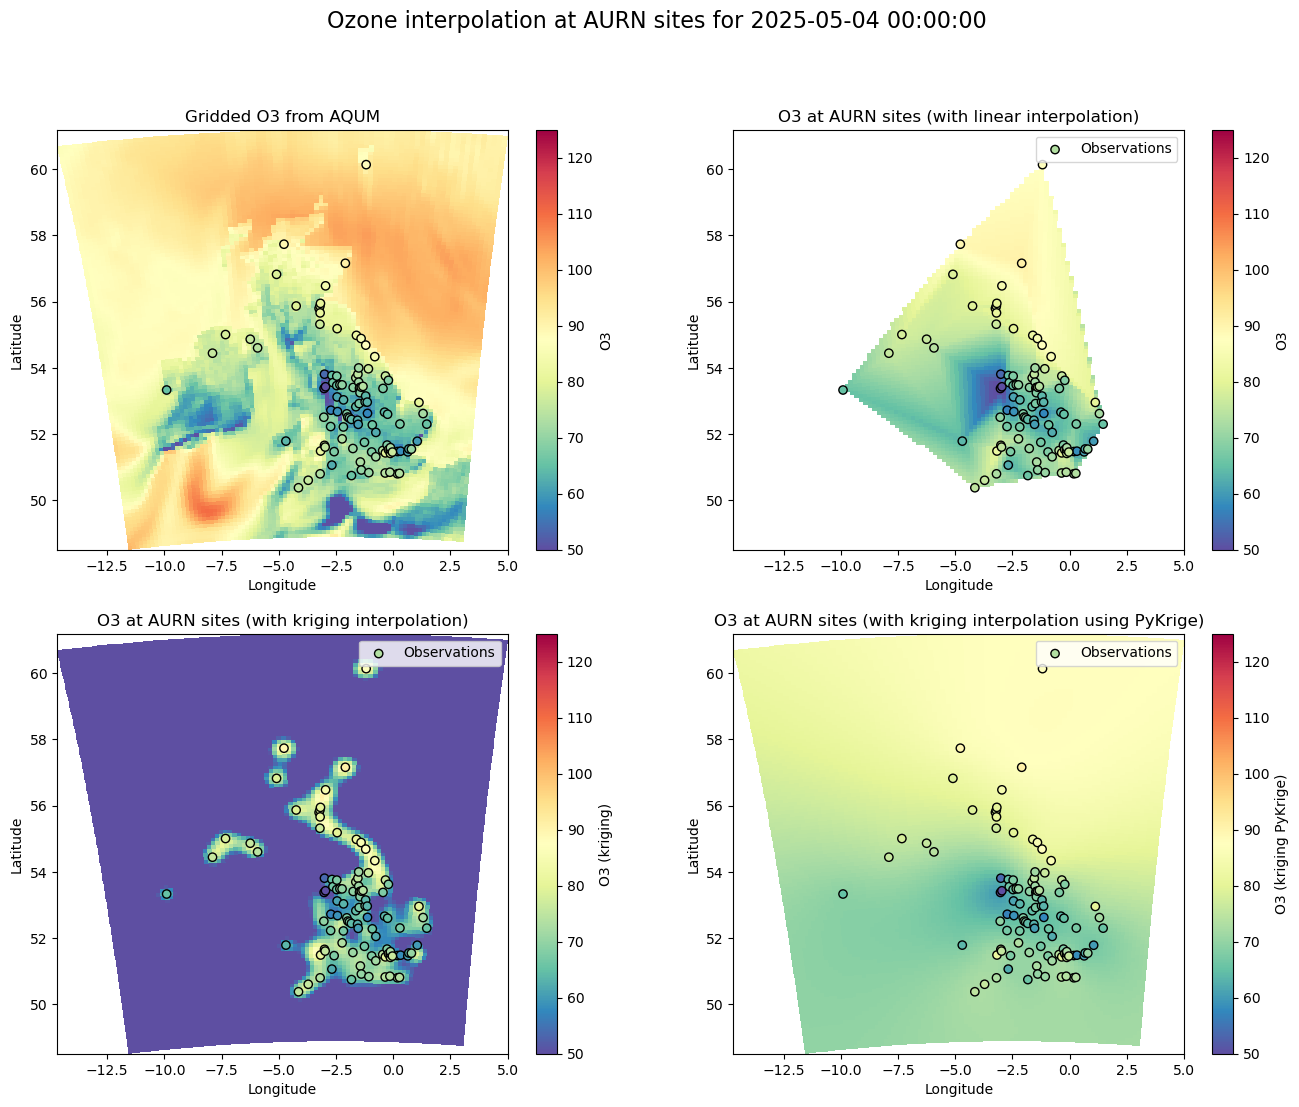

96 - Processing cubes for date: 2025-05-05 00:00:00


/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging


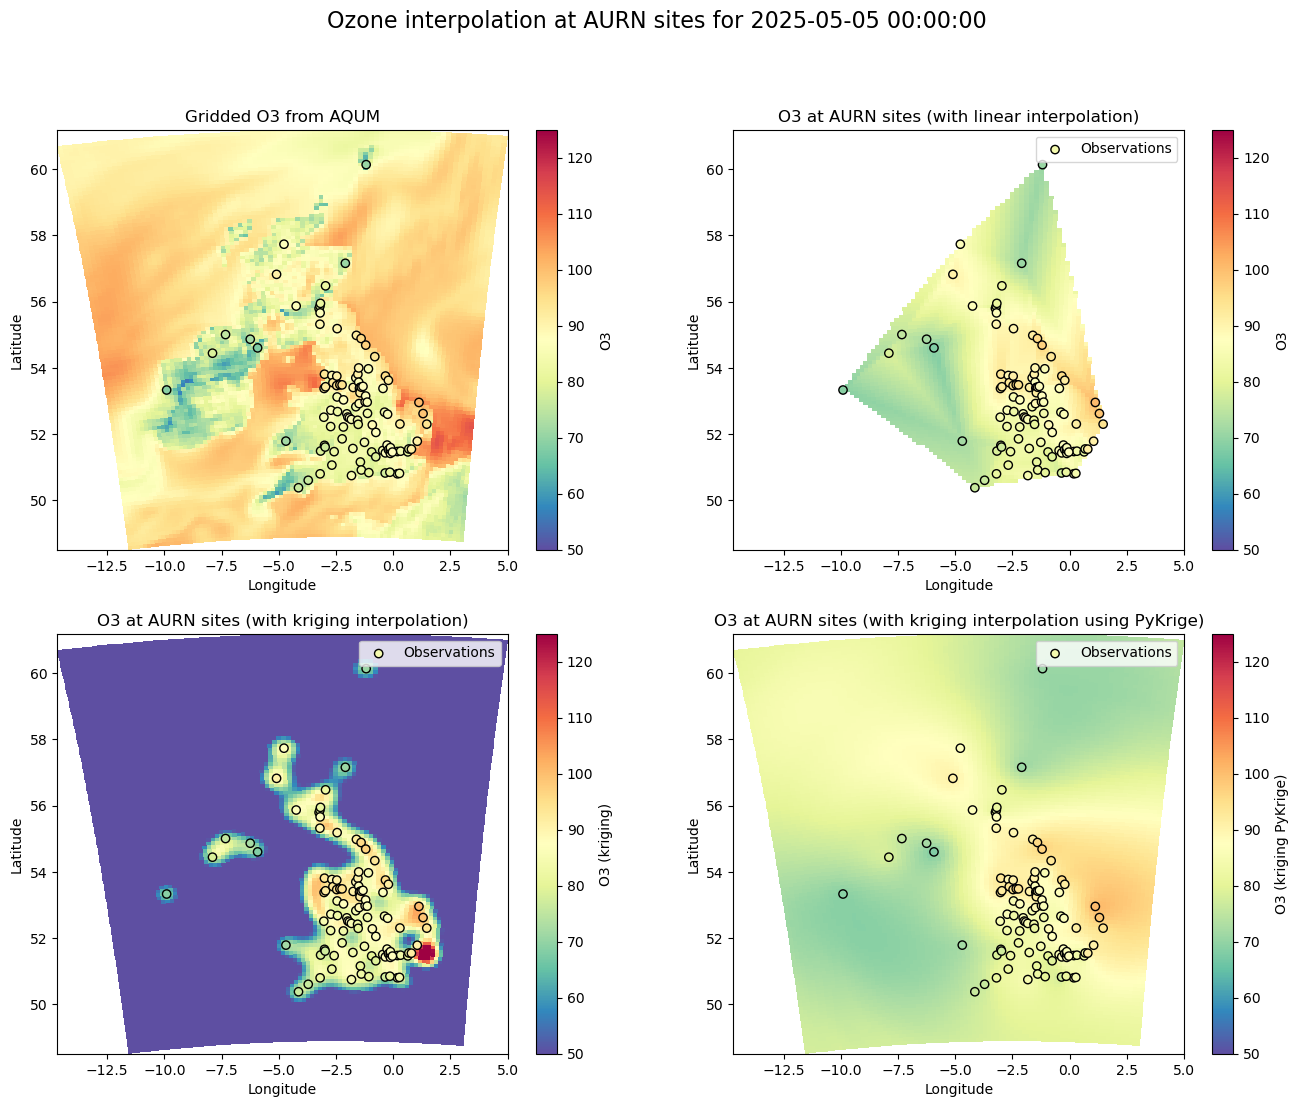

In [7]:
for i, (ozone_field_cube, ozone_at_site_cube) in enumerate(zip(ozone_gridded.slices_over('time'), ozone_sites.slices_over('time'))):

    # make a plot every 24 iterations (i.e., every day for hourly data)
    if i % 24 != 0:
        continue
    
    # stop after 5 days (120 hours)
    if i >= 120:
        break

    time_coord = ozone_field_cube.coord('time')
    dt = time_coord.units.num2date(time_coord.points)       # returns an array-like of datetimes
    date_str = dt[0].strftime("%Y-%m-%d %H:%M:%S")          # format as you like
    print(f'{i} - Processing cubes for date: {date_str}')

    sites_lat = []
    sites_lon = []
    sites_rotated_lat = []
    sites_rotated_lon = []
    sites_ozone = []

    # unpack the site_cube data and coords
    for site in ozone_at_site_cube.slices_over('site_id'):

        # Read sites values, lat/lon and rotated lat/lon from the cube coordinates
        # site_id = site.coord('site_id').points[0]
        site_lat = site.coord('latitude').points[0]
        site_lon = site.coord('longitude').points[0]
        site_rotated_lat = site.coord('grid_latitude').points[0]
        site_rotated_lon = site.coord('grid_longitude').points[0]

        # print(f"Site ID: {site_id}")
        # print(f"Site lat: {site_lat}, Site lon: {site_lon}")
        # print(f"Site rotated lat: {site_rotated_lat}, Site rotated lon: {site_rotated_lon}")

        # Append the values to the lists
        sites_ozone.append(site.data)
        sites_lat.append(site_lat)
        sites_lon.append(site_lon)
        sites_rotated_lat.append(site_rotated_lat)
        sites_rotated_lon.append(site_rotated_lon)

    if i == 0:
        # -----------------------------------
        # Define the unrotated grid for AQUM
        # -----------------------------------

        # Rotated pole properties
        pole_lon = ozone_field_cube.coord('grid_longitude').coord_system.grid_north_pole_longitude
        pole_lat = ozone_field_cube.coord('grid_latitude').coord_system.grid_north_pole_latitude

        lat_grid = ozone_field_cube.coord('grid_latitude').points
        lon_grid = ozone_field_cube.coord('grid_longitude').points - 360.0
        # print(f"\nTarget lat grid: {lat_grid}")
        # print(f"\nTarget lon grid: {lon_grid}")

        lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
        lon2d_unrotated, lat2d_unrotated = unrotate_pole(lon2d, lat2d, pole_lon, pole_lat)

    # -------------------------
    # Do the interpolation
    # -------------------------
    interpolated_values, kriging_values, kriging_v2_values, interpol_type = interpolation(
        sites_ozone, sites_rotated_lat, sites_rotated_lon, lon_grid, lat_grid
    )

    # -------------------------
    # Plotting the original gridded field and site locations with interpolated values
    # -------------------------
    plotting_interpolated_fields(ozone_field_cube,
                                np.array(sites_ozone),
                                 interpolated_values,
                                 kriging_values,
                                 kriging_v2_values,
                                 date_str,
                                 interpol_type,
                                 np.array(sites_lat),
                                 np.array(sites_lon),
                                 lon2d_unrotated,
                                 lat2d_unrotated
                                )

## Show orography

surface_altitude / (m)              (grid_latitude: 182; grid_longitude: 146)
    Dimension coordinates:
        grid_latitude                             x                    -
        grid_longitude                            -                    x
    Attributes:
        STASH                       m01s00i033
        source                      'Data from Met Office Unified Model'
        um_version                  '8.4'


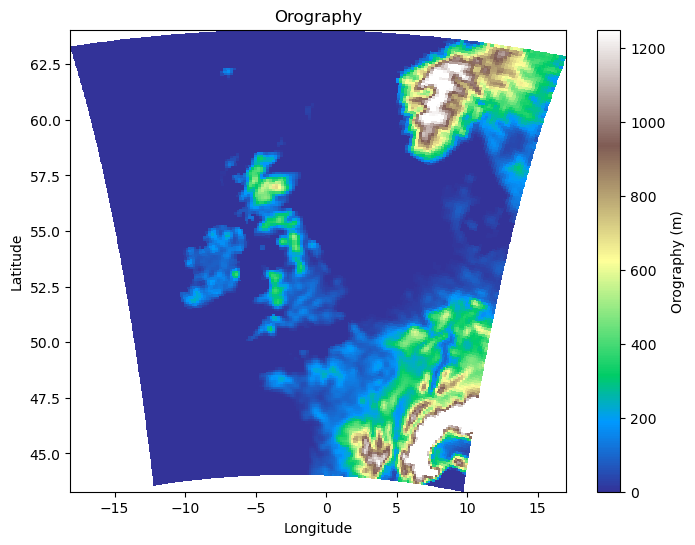

In [6]:
# load surface altitude from a pp_file
file_pp = './qrparm.orog'
orog_constratint = iris.AttributeConstraint(STASH="m01s00i033")
orog = iris.load_cube(file_pp, orog_constratint)
print(f"{orog}")
lat_grid = orog.coord('grid_latitude').points
lon_grid = orog.coord('grid_longitude').points - 360.0

lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)
pole_lon = orog.coord('grid_longitude').coord_system.grid_north_pole_longitude
pole_lat = orog.coord('grid_latitude').coord_system.grid_north_pole_latitude
lon2d_unrotated, lat2d_unrotated = unrotate_pole(lon2d, lat2d, pole_lon, pole_lat)

# plot orog
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)
pcm = ax.pcolormesh(lon2d_unrotated, lat2d_unrotated,
                    orog.data, cmap='terrain',
                    shading='auto', 
                    rasterized=True,
                    vmin=0, vmax=1250
                    )
fig.colorbar(pcm, ax=ax, label='Orography (m)')
ax.set_title('Orography')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()  